## Plots for the group project


In [1]:
import plotters as pl
import pandas as pd
import numpy as np
import helper_functions as hf

In [23]:
cv_prm_df = pd.read_csv("cluster_wise_permutation_test_metrics.csv")
vv_prm_df = pd.read_csv("voxel_wise_permutation_test_metrics.csv")
vv_rft_df = pd.read_csv("voxel_wise_rft_test_metrics.csv")


cv_prm_df = cv_prm_df.rename(columns={"n_subj" : "n"})

vv_rft_df[(vv_rft_df["sm_sigma"]==0) &  (vv_rft_df["snr"]==0) & (vv_rft_df["n"]==5)]


,fwer,sensitivity,sm_sigma,snr,n,method
196,0.0,0.0,0.0,0.0,5,voxelwise_rft


In [ ]:
final_metrics_df = pd.concat([cv_prm_df, vv_prm_df, vv_rft_df], ignore_index=True)
final_metrics_df

,fwer,sensitivity,sm_sigma,snr,n,method
0,0.00,0.000000,0.0,0.00,2,clusterwise_perm
1,0.00,0.000000,0.0,0.10,2,clusterwise_perm
2,0.00,0.000000,0.0,0.25,2,clusterwise_perm
3,0.00,0.000000,0.0,0.50,2,clusterwise_perm
4,0.00,0.000000,0.0,0.75,2,clusterwise_perm
...,...,...,...,...,...,...
5287,0.10,0.352472,3.0,2.00,60,voxelwise_rft
5288,0.00,0.362533,3.0,2.25,60,voxelwise_rft
5289,0.00,0.373330,3.0,2.50,60,voxelwise_rft
5290,0.05,0.378664,3.0,2.75,60,voxelwise_rft


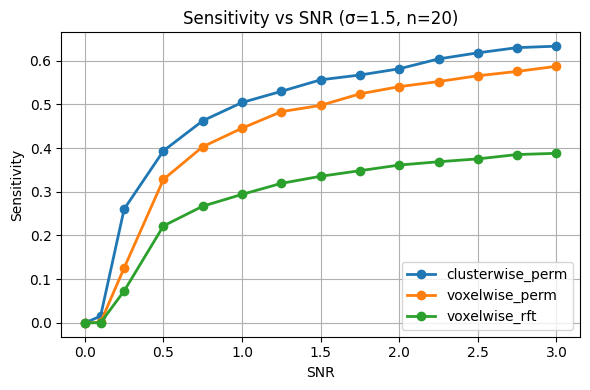

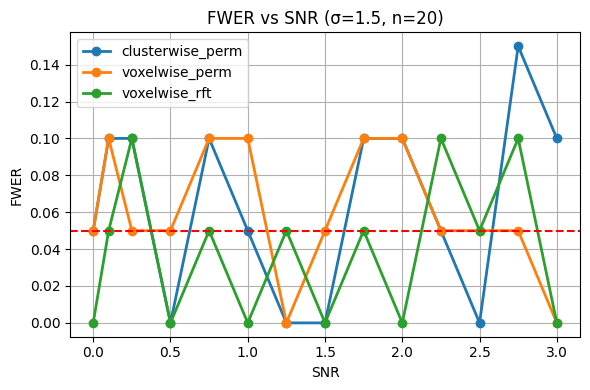

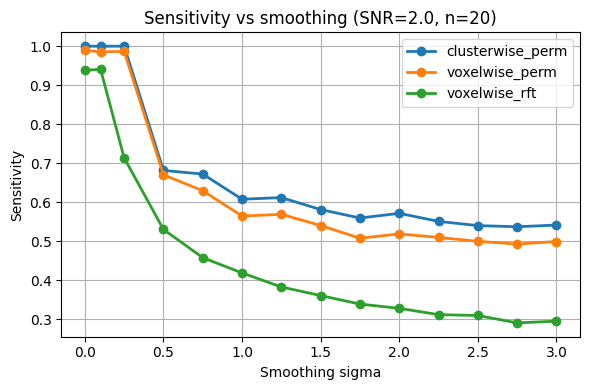

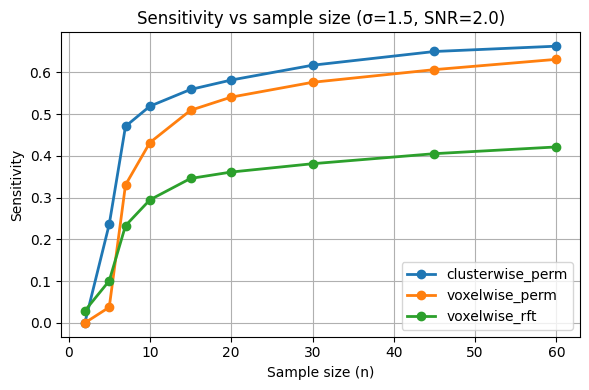

In [4]:
pl.plot_sensitivity_vs_snr(final_metrics_df) # Important: those methods will iterate through all unique methods in the "method" column in the dataframe
pl.plot_fwer_vs_snr(final_metrics_df)
pl.plot_sensitivity_vs_sigma(final_metrics_df)
pl.plot_sensitivity_vs_n(final_metrics_df)

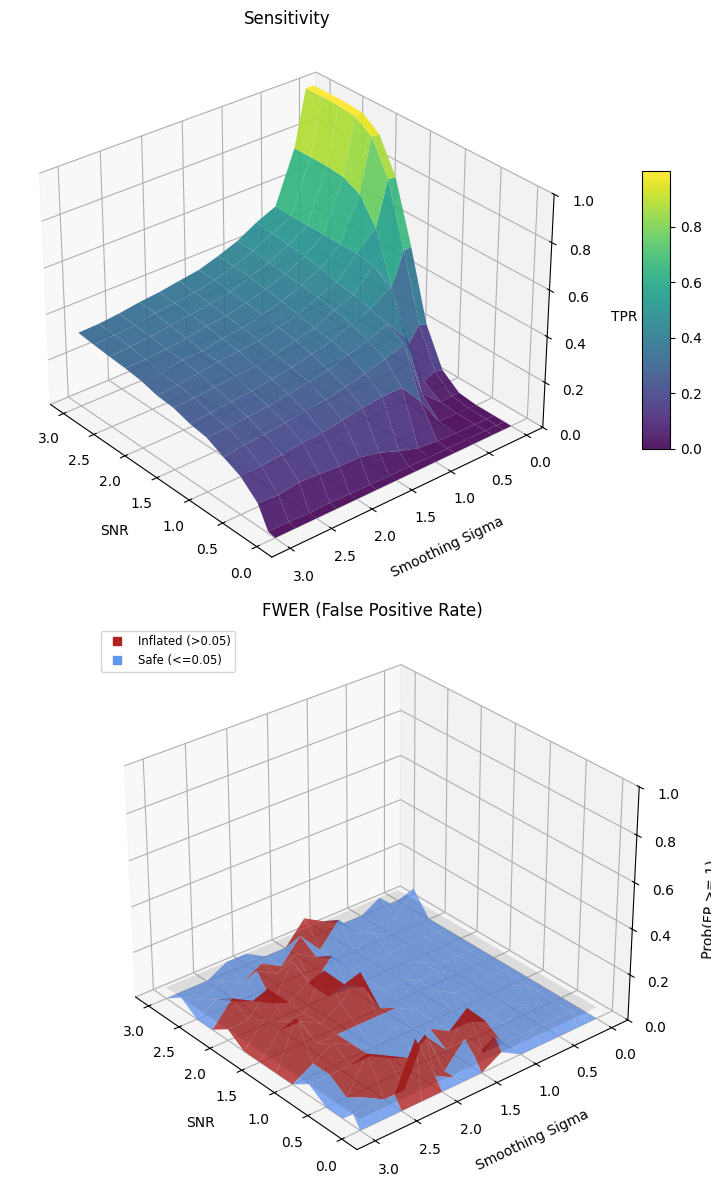

In [24]:

test_snrs =     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
n_values = [2,5,7,10,15,20,30,45,60]

sens_mat, fwer_mat = hf.reconstruct_metric_matrices(df = vv_rft_df, n_value = 20, sigma_levels = test_sigmas, snr_levels = test_snrs, method = "voxelwise_rft")
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)